In [ ]:
import pandas as pd
import pickle
from sklearn.cluster import KMeans

job_corpus = pd.read_csv("../data/processed/job_corpus_final.csv")

with open("../models/job_tfidf_vectorizer.pkl", "rb") as f:
    job_tfidf = pickle.load(f)
with open("../data/processed/job_vectors.pkl", "rb") as f:
    job_vectors = pickle.load(f)

print("Job corpus:", job_corpus.shape)
print("Job vectors:", job_vectors.shape)

Job corpus: (61019, 8)
Job vectors: (61019, 10000)


k=2, inertia=4711.14
k=3, inertia=4661.52
k=4, inertia=4618.94
k=5, inertia=4576.35
k=6, inertia=4538.44
k=7, inertia=4506.43
k=8, inertia=4476.82
k=9, inertia=4449.72
k=10, inertia=4446.88
k=11, inertia=4419.97
k=12, inertia=4407.27
k=13, inertia=4396.08
k=14, inertia=4379.03


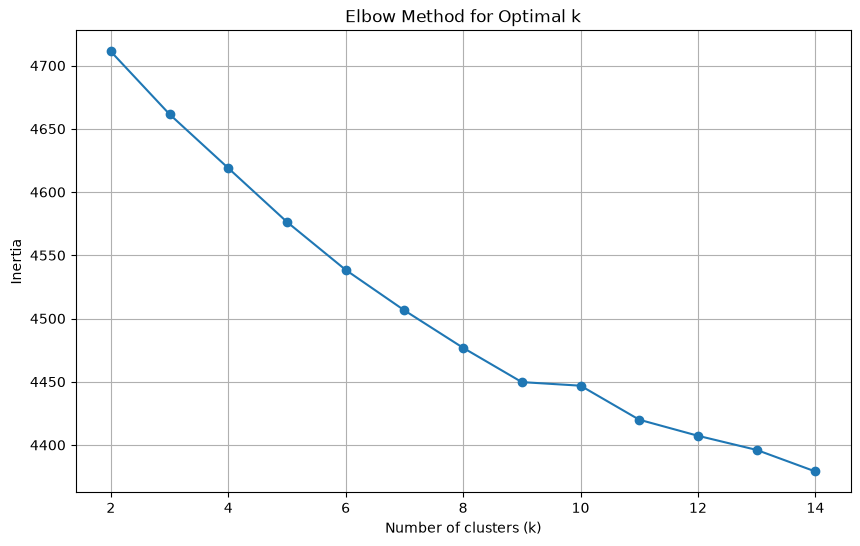

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
import numpy as np

# Sample for speed during elbow search
np.random.seed(42)
sample_size = 5000
sample_indices = np.random.choice(job_vectors.shape[0], sample_size, replace=False)
sample_vectors = job_vectors[sample_indices]

inertias = []
k_range = range(2, 15)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(sample_vectors)
    inertias.append(km.inertia_)
    print(f"k={k}, inertia={km.inertia_:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.savefig("../reports/figures/elbow_method.png", dpi=150)
plt.show()

In [ ]:
silhouette_scores = {}

for k in [4, 6, 8, 10, 12]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(sample_vectors)
    score = silhouette_score(sample_vectors, labels, sample_size=2000, random_state=42)
    silhouette_scores[k] = score
    print(f"k={k}, silhouette={score:.4f}")

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\nBest k by silhouette score: {best_k}")

k=4, silhouette=0.0201
k=6, silhouette=0.0192
k=8, silhouette=0.0217
k=10, silhouette=0.0235
k=12, silhouette=0.0265

Best k by silhouette score: 12


In [ ]:
final_k = 10

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
job_corpus["cluster"] = kmeans_final.fit_predict(job_vectors)

print("Cluster sizes:")
print(job_corpus["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0     1998
1    12286
2     8643
3      586
4     3807
5    15807
6     2609
7     7817
8     5345
9     2121
Name: count, dtype: int64


In [ ]:
def get_top_keywords_per_cluster(kmeans_model, vectorizer, n_words=10):
    feature_names = vectorizer.get_feature_names_out()
    centers = kmeans_model.cluster_centers_
    
    for i, center in enumerate(centers):
        top_indices = center.argsort()[::-1][:n_words]
        top_words = [feature_names[idx] for idx in top_indices]
        cluster_size = (job_corpus["cluster"] == i).sum()
        print(f"Cluster {i} (size={cluster_size}): {', '.join(top_words)}")

get_top_keywords_per_cluster(kmeans_final, job_tfidf)

Cluster 0 (size=1998): voice, process, international, bpo, customer, hiring, support, inbound, shift, chat
Cluster 1 (size=12286): work, experience, team, ability, including, store, customer, time, position, skills
Cluster 2 (size=8643): doctorate, profile, specialization, job, description, role, required, company, hr, industry
Cluster 3 (size=586): rs, teaching, pay, band, academic, date, advertisement, professor, iitb, ac
Cluster 4 (size=3807): sales, business, retail, development, doctorate, manager, profile, marketing, role, job
Cluster 5 (size=15807): management, operations, engineer, experience, development, technical, business, developer, application, senior
Cluster 6 (size=2609): care, nursing, patient, nurse, patients, healthcare, registered, rn, health, medical
Cluster 7 (size=7817): software, programming, doctorate, application, design, profile, developer, experience, description, role
Cluster 8 (size=5345): data, analytics, science, learning, machine, analysis, python, expe

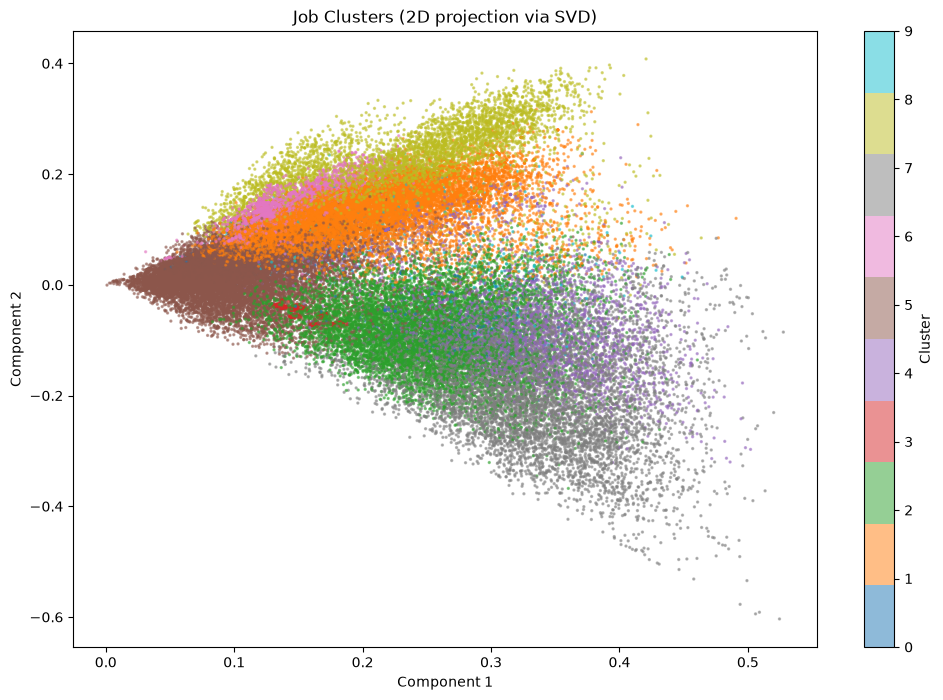

In [ ]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# TruncatedSVD works on sparse matrices (regular PCA doesn't) - reduces to 2D for plotting
svd = TruncatedSVD(n_components=2, random_state=42)
vectors_2d = svd.fit_transform(job_vectors)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=job_corpus["cluster"], cmap="tab10", s=2, alpha=0.5)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("Job Clusters (2D projection via SVD)")
plt.savefig("../reports/figures/clusters_2d.png", dpi=150)
plt.show()

In [ ]:
import pickle

with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans_final, f)

job_corpus.to_csv("../data/processed/job_corpus_clustered.csv", index=False)

print("Saved clustering model and clustered corpus.")

Saved clustering model and clustered corpus.


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def get_cluster_top_skills(cluster_id, n_words=15):
    """Get the defining keywords for a given cluster from the KMeans center."""
    feature_names = job_tfidf.get_feature_names_out()
    center = kmeans_final.cluster_centers_[cluster_id]
    top_indices = center.argsort()[::-1][:n_words]
    return set(feature_names[idx] for idx in top_indices)

def skill_gap_report(resume_text, top_n_skills=15):
    # Step 1: clean and vectorize the resume
    cleaned = clean_text(resume_text)
    resume_vector = job_tfidf.transform([cleaned])
    
    # Step 2: predict which cluster this resume is closest to
    predicted_cluster = kmeans_final.predict(resume_vector)[0]
    
    # Step 3: get that cluster's defining skills
    cluster_skills = get_cluster_top_skills(predicted_cluster, top_n_skills)
    
    # Step 4: check which of those skills are missing from the resume text
    resume_words = set(cleaned.split())
    matched_skills = cluster_skills & resume_words
    missing_skills = cluster_skills - resume_words
    
    return {
        "predicted_cluster": predicted_cluster,
        "matched_skills": matched_skills,
        "missing_skills": missing_skills
    }

# Test it
sample_resume = resumes[resumes["Category"] == "ACCOUNTANT"].iloc[0]["Resume"]
report = skill_gap_report(sample_resume)

print("Predicted cluster:", report["predicted_cluster"])
print("\nSkills you already show:", report["matched_skills"])
print("\nSkills to consider adding:", report["missing_skills"])

Predicted cluster: 1

Skills you already show: {'time', 'experience', 'team', 'skills', 'work', 'business', 'including'}

Skills to consider adding: {'management', 'store', 'ability', 'customer', 'benefits', 'support', 'position', 'service'}


In [ ]:
resumes = pd.read_csv("../data/processed/resumes_clean.csv")

sample_resume = resumes[resumes["Category"] == "ACCOUNTANT"].iloc[0]["Resume"]
report = skill_gap_report(sample_resume)

print("Predicted cluster:", report["predicted_cluster"])
print("\nSkills you already show:", report["matched_skills"])
print("\nSkills to consider adding:", report["missing_skills"])

Predicted cluster: 1

Skills you already show: {'time', 'experience', 'team', 'skills', 'work', 'business', 'including'}

Skills to consider adding: {'management', 'store', 'ability', 'customer', 'benefits', 'support', 'position', 'service'}


In [ ]:
from collections import Counter

GENERIC_WORDS = {
    "experience", "work", "team", "skills", "role", "profile", "position", "job",
    "description", "required", "company", "industry", "ability", "including",
    "time", "date", "business", "management", "customer", "service", "support"
}

def get_cluster_top_skills_v2(cluster_id, n_words=15):
    """Extract real skill keywords from the 'skills' column of jobs in this cluster."""
    cluster_jobs = job_corpus[job_corpus["cluster"] == cluster_id]
    all_skills_text = " ".join(cluster_jobs["skills"].dropna().astype(str)).lower()
    
    # Split on common delimiters used in skills fields
    tokens = re.split(r"[,/|]", all_skills_text)
    tokens = [t.strip() for t in tokens if t.strip() and len(t.strip()) > 2]
    tokens = [t for t in tokens if t not in GENERIC_WORDS]
    
    counter = Counter(tokens)
    return set(word for word, _ in counter.most_common(n_words))

def skill_gap_report_v2(resume_text, top_n_skills=15):
    cleaned = clean_text(resume_text)
    resume_vector = job_tfidf.transform([cleaned])
    predicted_cluster = kmeans_final.predict(resume_vector)[0]
    
    cluster_skills = get_cluster_top_skills_v2(predicted_cluster, top_n_skills)
    resume_words = set(cleaned.split())
    
    matched = {s for s in cluster_skills if any(w in resume_words for w in s.split())}
    missing = cluster_skills - matched
    
    return {
        "predicted_cluster": predicted_cluster,
        "matched_skills": matched,
        "missing_skills": missing
    }

report = skill_gap_report_v2(sample_resume)
print("Predicted cluster:", report["predicted_cluster"])
print("\nSkills you already show:", report["matched_skills"])
print("\nSkills to consider adding:", report["missing_skills"])

Predicted cluster: 1

Skills you already show: {'word', 'powerpoint', 'people skills', 'excel'}

Skills to consider adding: {'teaching', 'dental', 'english as a secondary language (esl)', 'sharepoint', 'fundraising', 'market research', 'scikit-learn', 'religion', 'pandas', 'well-documented', 'numpy'}


In [ ]:
def skill_gap_report_v3(resume_text, top_n_jobs=15, top_n_skills=15):
    cleaned = clean_text(resume_text)
    resume_vector = job_tfidf.transform([cleaned])
    
    # Reuse the recommender logic: find the most similar actual jobs
    similarities = cosine_similarity(resume_vector, job_vectors).flatten()
    top_indices = similarities.argsort()[::-1][:top_n_jobs]
    top_jobs = job_corpus.iloc[top_indices]
    
    # Pull real skills from these specific top-matching jobs (not a whole vague cluster)
    all_skills_text = " ".join(top_jobs["skills"].dropna().astype(str)).lower()
    tokens = re.split(r"[,/|]", all_skills_text)
    tokens = [t.strip() for t in tokens if t.strip() and len(t.strip()) > 2]
    tokens = [t for t in tokens if t not in GENERIC_WORDS]
    
    counter = Counter(tokens)
    top_skills = set(word for word, _ in counter.most_common(top_n_skills))
    
    resume_words = set(cleaned.split())
    matched = {s for s in top_skills if any(w in resume_words for w in s.split())}
    missing = top_skills - matched
    
    return {
        "matched_skills": matched,
        "missing_skills": missing,
        "based_on_jobs": top_jobs["title"].head(5).tolist()
    }

from sklearn.metrics.pairwise import cosine_similarity

report = skill_gap_report_v3(sample_resume)
print("Based on jobs like:", report["based_on_jobs"])
print("\nSkills you already show:", report["matched_skills"])
print("\nSkills to consider adding:", report["missing_skills"])

Based on jobs like: ['Senior Staff Accountant', 'Walk-in for GL Accounting (senior Associate) role in EXL', 'Accountant', 'Accountant', 'Accountant 1- Fin']

Skills you already show: {'accounts accounts accounts'}

Skills to consider adding: set()


In [ ]:
top_jobs_check = job_corpus.iloc[
    cosine_similarity(job_tfidf.transform([clean_text(sample_resume)]), job_vectors)
    .flatten().argsort()[::-1][:15]
]

for idx, row in top_jobs_check.head(5).iterrows():
    print(f"Title: {row['title']}")
    print(f"Skills raw: {repr(row['skills'])}")
    print()

Title: Senior Staff Accountant
Skills raw: nan

Title: Walk-in for GL Accounting (senior Associate) role in EXL
Skills raw: 'Accounts'

Title: Accountant
Skills raw: nan

Title: Accountant
Skills raw: nan

Title: Accountant 1- Fin
Skills raw: 'Accounts'



In [ ]:
job_corpus["skills"] = job_corpus["skills"].fillna("")

def skill_gap_report_v4(resume_text, top_n_jobs=15, top_n_skills=15):
    cleaned = clean_text(resume_text)
    resume_vector = job_tfidf.transform([cleaned])
    
    similarities = cosine_similarity(resume_vector, job_vectors).flatten()
    top_indices = similarities.argsort()[::-1][:top_n_jobs]
    top_jobs = job_corpus.iloc[top_indices]
    
    # Tokenize properly: split on whitespace AND common delimiters, clean each word
    all_skills_text = " ".join(top_jobs["skills"].astype(str))
    all_skills_text = re.sub(r"[,/|]", " ", all_skills_text)  # normalize delimiters to spaces
    tokens = clean_text(all_skills_text).split()  # reuse our existing cleaner, then split on whitespace
    tokens = [t for t in tokens if len(t) > 2 and t not in GENERIC_WORDS]
    
    counter = Counter(tokens)
    top_skills = set(word for word, _ in counter.most_common(top_n_skills))
    
    resume_words = set(cleaned.split())
    matched = top_skills & resume_words
    missing = top_skills - matched
    
    return {
        "matched_skills": matched,
        "missing_skills": missing,
        "based_on_jobs": top_jobs["title"].head(5).tolist()
    }

report = skill_gap_report_v4(sample_resume)
print("Based on jobs like:", report["based_on_jobs"])
print("\nSkills you already show:", report["matched_skills"])
print("\nSkills to consider adding:", report["missing_skills"])

Based on jobs like: ['Senior Staff Accountant', 'Walk-in for GL Accounting (senior Associate) role in EXL', 'Accountant', 'Accountant', 'Accountant 1- Fin']

Skills you already show: {'accounts'}

Skills to consider adding: set()


In [ ]:
wider_jobs = job_corpus.iloc[
    cosine_similarity(job_tfidf.transform([clean_text(sample_resume)]), job_vectors)
    .flatten().argsort()[::-1][:100]
]

print("Skills field value counts among top 100 matches:")
print(wider_jobs["skills"].replace("", "EMPTY").value_counts().head(15))

print("\nSource breakdown of top 100 matches:")
print(wider_jobs["source"].value_counts())

Skills field value counts among top 100 matches:
skills
EMPTY             63
Accounts          36
Top Management     1
Name: count, dtype: int64

Source breakdown of top 100 matches:
source
naukri      63
linkedin    37
Name: count, dtype: int64


In [ ]:
def skill_gap_report_final(resume_text, top_n_jobs=20, top_n_skills=15):
    cleaned = clean_text(resume_text)
    resume_vector = job_tfidf.transform([cleaned])
    resume_words = set(cleaned.split())
    
    similarities = cosine_similarity(resume_vector, job_vectors).flatten()
    top_indices = similarities.argsort()[::-1][:top_n_jobs]
    top_jobs = job_corpus.iloc[top_indices]
    
    # Average the TF-IDF vectors of the top matching jobs -> which words matter most for this "job family"
    avg_vector = job_vectors[top_indices].mean(axis=0)
    avg_vector = np.asarray(avg_vector).flatten()
    
    feature_names = job_tfidf.get_feature_names_out()
    top_word_indices = avg_vector.argsort()[::-1][:100]  # grab a wide pool first
    
    candidate_words = [feature_names[i] for i in top_word_indices]
    candidate_words = [w for w in candidate_words if w not in GENERIC_WORDS and len(w) > 2]
    
    matched = [w for w in candidate_words if w in resume_words][:top_n_skills]
    missing = [w for w in candidate_words if w not in resume_words][:top_n_skills]
    
    return {
        "matched_skills": matched,
        "missing_skills": missing,
        "based_on_jobs": top_jobs["title"].head(5).tolist()
    }

import numpy as np
report = skill_gap_report_final(sample_resume)
print("Based on jobs like:", report["based_on_jobs"])
print("\nSkills you already show:", report["matched_skills"])
print("\nSkills to consider adding:", report["missing_skills"])

Based on jobs like: ['Senior Staff Accountant', 'Walk-in for GL Accounting (senior Associate) role in EXL', 'Accountant', 'Accountant', 'Accountant 1- Fin']

Skills you already show: ['accounting', 'financial', 'accountant', 'tax', 'accounts', 'ledger', 'statements', 'entries', 'journal', 'reconciliations', 'general', 'prepare', 'monthly', 'payable', 'reporting']

Skills to consider adding: ['staff', 'receivable', 'assist', 'transactions', 'preparing', 'accurate', 'internal', 'senior', 'timely', 'related', 'reconciliation', 'processing', 'records', 'controller', 'degree']


In [ ]:
job_corpus.to_csv("../data/processed/job_corpus_final_v2.csv", index=False)
print("Saved final job corpus with skills fix.")

Saved final job corpus with skills fix.
